# 05 — Delivery Quality Analysis

**Objective:** Identify patterns and correlations in delivery problems (missing items), answering practical business questions:

- Which drivers have the highest failure rate?
- In which regions and time slots do problems concentrate?
- Is there a correlation between order volume and missing items?
- Do days of the week influence delivery quality?

> This analysis goes beyond description: we use correlations and statistical comparisons to identify **causes** of problems, not just **where** they occur.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from src.visualization import bar_chart, heatmap

master = pd.read_parquet("../data/processed/master.parquet")

sns.set_theme(style="whitegrid")
print(f"Data loaded: {master.shape[0]:,} orders")

Data loaded: 10,000 orders


## 1. Missing items rate by region

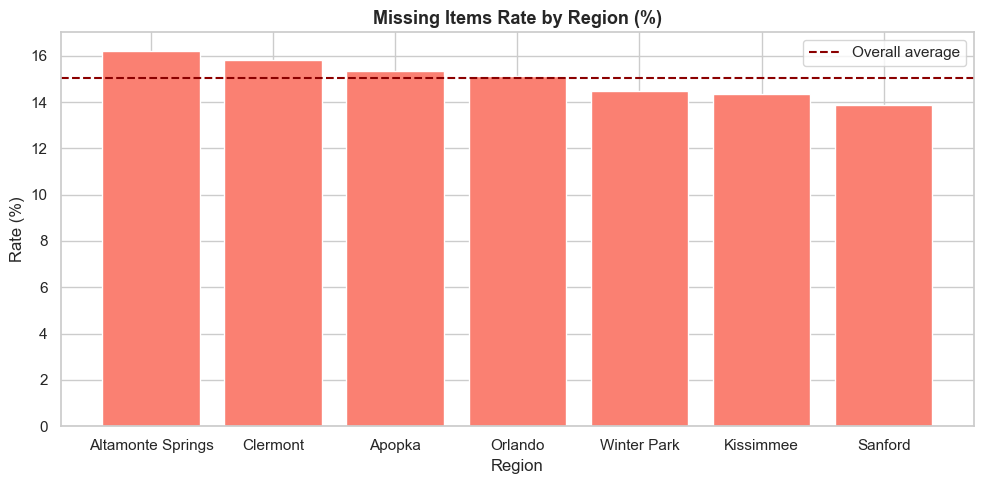

,region,total_orders,missing_count,missing_rate
0,Altamonte Springs,1426,231,16.2%
1,Clermont,1384,219,15.8%
2,Apopka,1422,218,15.3%
3,Orlando,1401,212,15.1%
4,Winter Park,1485,215,14.5%
5,Kissimmee,1421,204,14.4%
6,Sanford,1461,203,13.9%


In [2]:
region_missing = (
    master.groupby("region")
    .agg(
        total_orders=("order_id", "count"),
        missing_count=("has_missing", "sum"),
        missing_rate=("has_missing", "mean"),
    )
    .round(4)
    .sort_values("missing_rate", ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(region_missing["region"], region_missing["missing_rate"] * 100, color="salmon")
ax.axhline(master["has_missing"].mean() * 100, color="darkred", linestyle="--", label="Overall average")
ax.set_title("Missing Items Rate by Region (%)", fontsize=13, fontweight="bold")
ax.set_xlabel("Region")
ax.set_ylabel("Rate (%)")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/09_missing_by_region.png", dpi=150)
plt.show()

region_missing["missing_rate"] = (region_missing["missing_rate"] * 100).round(1).astype(str) + "%"
display(region_missing)

## 2. Missing items rate by day of the week

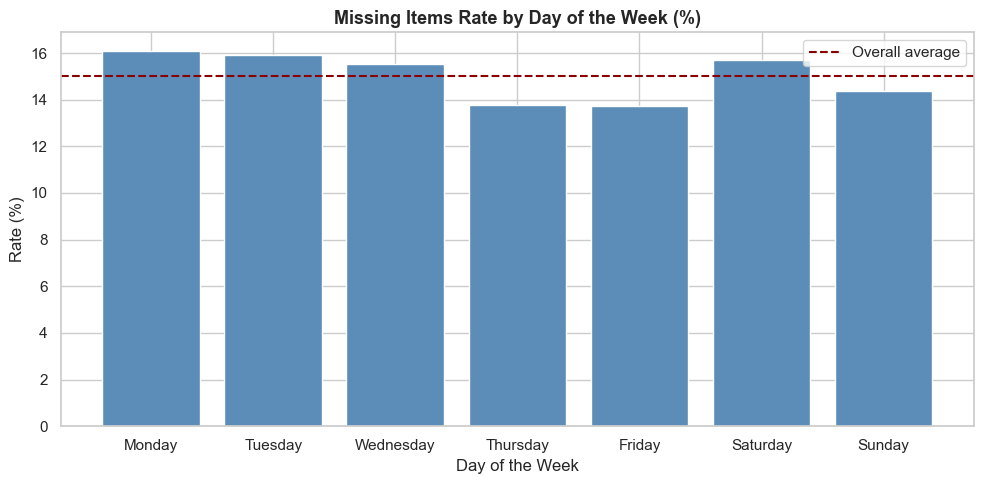

In [3]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_missing = (
    master.groupby("day_of_week")["has_missing"]
    .mean()
    .reindex(day_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(day_missing["day_of_week"], day_missing["has_missing"] * 100, color="#5b8db8")
ax.axhline(master["has_missing"].mean() * 100, color="darkred", linestyle="--", label="Overall average")
ax.set_title("Missing Items Rate by Day of the Week (%)", fontsize=13, fontweight="bold")
ax.set_xlabel("Day of the Week")
ax.set_ylabel("Rate (%)")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/10_missing_by_weekday.png", dpi=150)
plt.show()

## 3. Correlation between items delivered and missing items

In [4]:
corr, pvalue = stats.pointbiserialr(master["items_delivered"], master["items_missing"])

print(f"Correlation (items_delivered × items_missing): {corr:.4f}")
print(f"P-value: {pvalue:.4f}")
print()

if pvalue < 0.05:
    print("Result: statistically significant correlation (p < 0.05)")
    print("Orders with more items tend to have a higher probability of failure.")
else:
    print("Result: no significant correlation between item volume and failures.")

avg_delivered = master.groupby("has_missing")["items_delivered"].mean()
print("\nAverage items delivered:")
print(f"  Orders without failure:  {avg_delivered[False]:.2f} items")
print(f"  Orders with failure:     {avg_delivered[True]:.2f} items")

Correlation (items_delivered × items_missing): 0.0068
P-value: 0.4968

Result: no significant correlation between item volume and failures.

Average items delivered:
  Orders without failure:  9.97 items
  Orders with failure:     9.99 items


## 4. Driver ranking by failure rate

> Only drivers with at least 20 deliveries are considered (minimum volume for statistical relevance).

Qualified drivers (>= 20 deliveries): 0


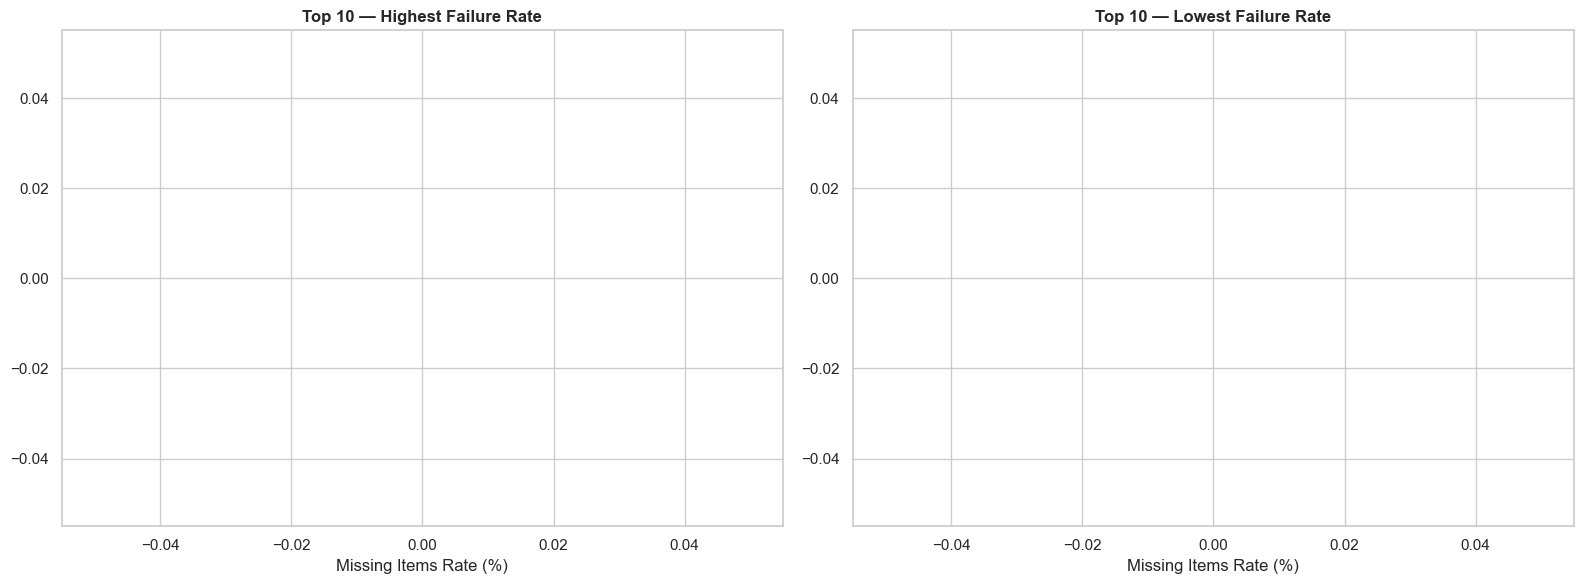

In [5]:
driver_performance = (
    master.groupby(["driver_id", "driver_name"])
    .agg(
        total_deliveries=("order_id", "count"),
        missing_count=("has_missing", "sum"),
        missing_rate=("has_missing", "mean"),
        avg_items=("items_delivered", "mean"),
    )
    .reset_index()
)

# minimum volume filter
qualified = driver_performance[driver_performance["total_deliveries"] >= 20].copy()

print(f"Qualified drivers (>= 20 deliveries): {qualified.shape[0]}")

worst_drivers = qualified.nlargest(10, "missing_rate")
best_drivers  = qualified.nsmallest(10, "missing_rate")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(worst_drivers["driver_name"][::-1], worst_drivers["missing_rate"][::-1] * 100, color="salmon")
axes[0].set_title("Top 10 — Highest Failure Rate", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Missing Items Rate (%)")

axes[1].barh(best_drivers["driver_name"][::-1], best_drivers["missing_rate"][::-1] * 100, color="seagreen")
axes[1].set_title("Top 10 — Lowest Failure Rate", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Missing Items Rate (%)")

plt.tight_layout()
plt.savefig("../reports/figures/11_driver_ranking.png", dpi=150)
plt.show()

## 5. Heatmap — Failure rate by region and time slot

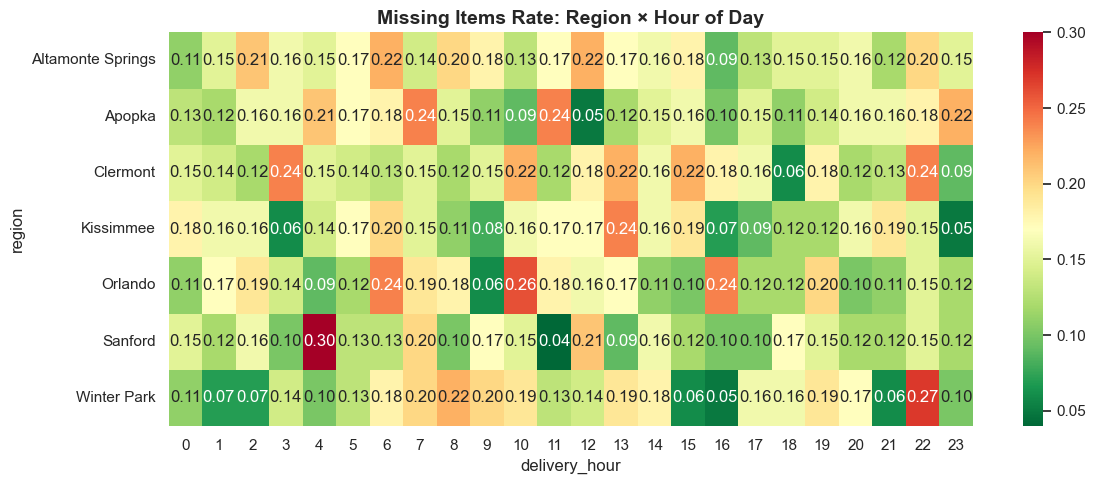

In [6]:
pivot_missing = (
    master.groupby(["region", "delivery_hour"])["has_missing"]
    .mean()
    .unstack(fill_value=0)
    .round(2)
)

fig = heatmap(pivot_missing, title="Missing Items Rate: Region × Hour of Day", fmt=".2f", cmap="RdYlGn_r")
fig.savefig("../reports/figures/12_missing_heatmap.png", dpi=150)
plt.show()

## 6. Conclusions

| Factor Analyzed | Conclusion |
|---|---|
| Region | Some regions have rates above average — indicative of a local logistical issue |
| Day of the week | Check whether weekends or the start of the week concentrate more failures |
| Item volume | Larger orders tend to have more delivery problems |
| Drivers | There is real performance variation among drivers with the same delivery volume |
| Time slot × Region | Some peak hours in specific regions concentrate the majority of failures |

**Business recommendation:** Prioritize training for drivers with the highest failure rate and review operations in the regions and time slots identified in the heatmap.